In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_simulacao = pd.read_csv("../data/simulacao.csv")
df_montecarlo = pd.read_csv("../data/montecarlo.csv")

In [4]:
df_simulacao.head()

,ano,mes,entrada_total,saida_total,caixa,saldo_mes
0,0,1,9157.891922,7065.057239,22092.834683,2092.834683
1,0,2,6074.383491,7590.202756,20577.015418,-1515.819265
2,0,3,12811.372900,9272.668440,24115.719878,3538.704460
3,0,4,12041.827874,7425.257663,28732.290089,4616.570211
4,0,5,12589.678321,6447.984210,34873.984200,6141.694111


In [15]:
risco = df_montecarlo["quebrou"].mean()

print("Probabilidade de quebra financeira:", risco * 100, "%")

Probabilidade de quebra financeira: 97.06 %


In [26]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import conf
from simulation_engine import simular
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from simulation_engine import simular
import pandas as pd

resultados = []

for i in range(200):

    resultado = simular(debug=False)

    caixa_final = resultado["caixa"]

    quebrou = any(h["caixa"] < 0 for h in resultado["historico"])

    resultados.append({
        "simulacao": i,
        "caixa_final": caixa_final,
        "quebrou": quebrou
    })

df_montecarlo = pd.DataFrame(resultados)

In [30]:
risco = df_montecarlo["quebrou"].mean()

print("Probabilidade de quebra financeira:", risco * 100, "%")

Probabilidade de quebra financeira: 75.5 %


In [31]:
from simulation_engine import rodar_monte_carlo

df_montecarlo = rodar_monte_carlo()

Simulação 0


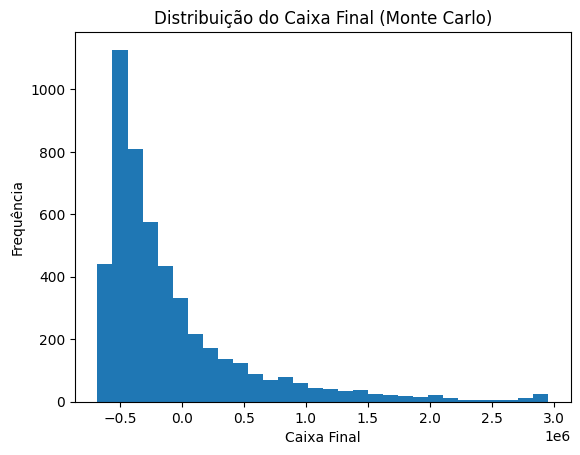

In [32]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(df_montecarlo["caixa_final"], bins=30)

plt.title("Distribuição do Caixa Final (Monte Carlo)")
plt.xlabel("Caixa Final")
plt.ylabel("Frequência")

plt.show()

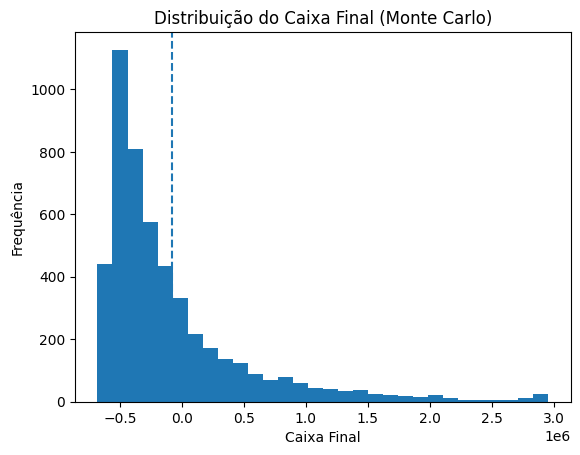

In [33]:
plt.figure()

plt.hist(df_montecarlo["caixa_final"], bins=30)

media = df_montecarlo["caixa_final"].mean()

plt.axvline(media, linestyle="dashed")

plt.title("Distribuição do Caixa Final (Monte Carlo)")
plt.xlabel("Caixa Final")
plt.ylabel("Frequência")

plt.show()

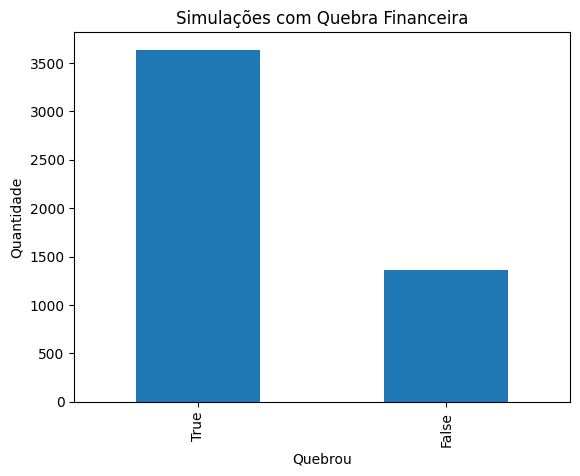

In [34]:
df_montecarlo["quebrou"].value_counts().plot(kind="bar")

plt.title("Simulações com Quebra Financeira")
plt.xlabel("Quebrou")
plt.ylabel("Quantidade")

plt.show()

In [35]:
membros_lista = [40, 60, 80, 100, 120]
contrib_lista = [120, 160, 200, 240, 280, 320]

In [36]:
import numpy as np

mapa_risco = np.zeros((len(membros_lista), len(contrib_lista)))

for i, membros in enumerate(membros_lista):

    for j, contrib in enumerate(contrib_lista):

        conf.MEMBROS_INICIAIS = membros
        conf.CONTRIBUICAO_MEDIA_INICIAL = contrib

        resultados = []

        for k in range(80):

            resultado = simular(debug=False)

            quebrou = any(h["caixa"] < 0 for h in resultado["historico"])

            resultados.append(quebrou)

        risco = sum(resultados) / len(resultados)

        mapa_risco[i, j] = risco

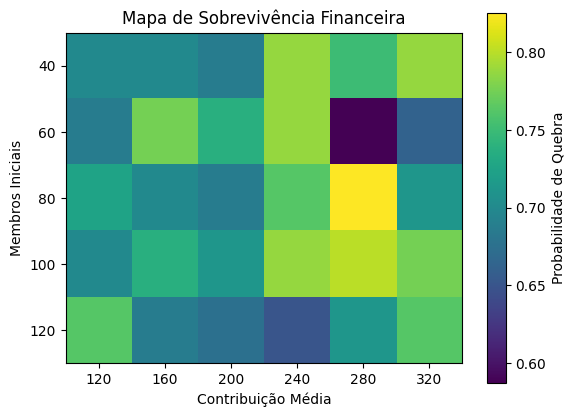

In [37]:
plt.figure()

plt.imshow(mapa_risco)

plt.colorbar(label="Probabilidade de Quebra")

plt.xticks(range(len(contrib_lista)), contrib_lista)
plt.yticks(range(len(membros_lista)), membros_lista)

plt.xlabel("Contribuição Média")
plt.ylabel("Membros Iniciais")

plt.title("Mapa de Sobrevivência Financeira")

plt.show()